# **TS1:** Primeros pasos en la simulación.
## Mariano Pittaluga.


### Consigna:
En este primer trabajo comenzaremos por diseñar un generador de señales que utilizaremos en las primeras simulaciones que hagamos. La primer tarea consistirá en programar una función que genere señales senoidales y que permita parametrizar:

    - la amplitud máxima de la senoidal (volts)
    - su valor medio (volts)
    - la frecuencia (Hz)
    - la fase (radianes)
    - la cantidad de muestras digitalizada por el ADC (# muestras)
    - la frecuencia de muestreo del ADC.

es decir que la función que uds armen debería admitir ser llamada de la siguiente manera

tt, xx = mi_funcion_sen( vmax = 1, dc = 0, ff = 1, ph=0, nn = N, fs = fs)

Recuerden que tanto xx como tt deben ser vectores de Nx1. Puede resultarte útil el módulo de visualización matplotlib.pyplot donde encontrarán todas las funciones de visualización estilo Matlab. Para usarlo:

    import matplotlib.pyplot as plt

    plt.plot(tt, xx)
    
### Bonus:

    💎 Ser el primero en subir un enlace a tu notebook en esta tarea
    🤯 Implementar alguna otra señal propia de un generador de señales. 

### Ayudas:

    - La función numpy.sin seguro te va a servir.
    - No hace falta usar ningún lazo de control for, while, etc.
    - Podés consultar en el chat cualquier duda o problema que vayas encontrando. Buena suerte!



## Resolución: 

In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy import signal as sig

# Condiciones de muestreo
N    = 1000 # Muestras
fs   = 1000 # AF = 1


### Función Generador de Señales:

In [2]:
def signal( wave ='sin', vmax=1, dc=0, ff=1, ph=0, nn=N, fs=fs, duty=0.5 ):
    
    tt = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    
    match wave:
        case 'sine':
            xx = vmax * np.sin( 2 * np.pi * ff * tt + ph) + dc
        case 'square':
            xx = vmax * sig.square( 2 * np.pi * ff * tt + ph, duty = duty) + dc
        case 'triangle':
            xx = vmax * sig.sawtooth( 2 * np.pi * ff * tt + ph, width=0.5) + dc
        case 'sawtooth':
            xx = vmax * sig.sawtooth( 2 * np.pi * ff * tt + ph) + dc
        case _:
            raise ValueError(f"Tipo '{wave}' no reconocido.")
    
    return tt, xx

## Gráficos: 
### Señal Senoidal:

In [3]:
# Parametros de la Señal
ff   = 5 # Hz
vmax = 1 
dc   = 0
ph   = np.pi

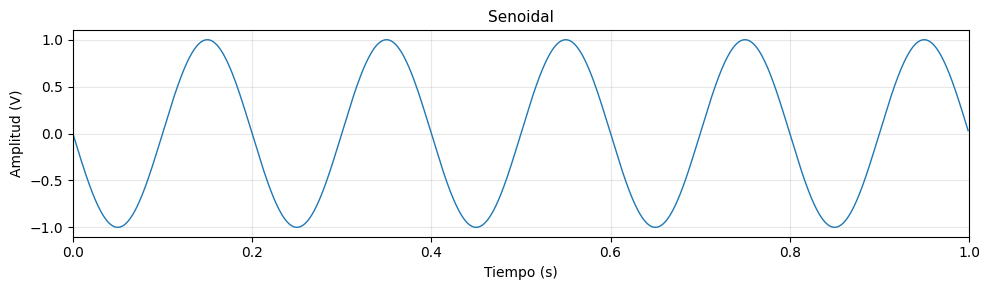

In [4]:
# Visualización
tt, xx = signal(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs, wave='sine')
plt.figure(figsize=(10, 3))
plt.plot(tt, xx, linewidth=1)
plt.title("Senoidal", fontsize=11)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.tight_layout()
plt.show()

### Señal Cuadrada:

In [5]:
# Parametros de la Señal
ff   = 5 # Hz
vmax = 2 
dc   = 1
ph   = 0
duty = 0.75

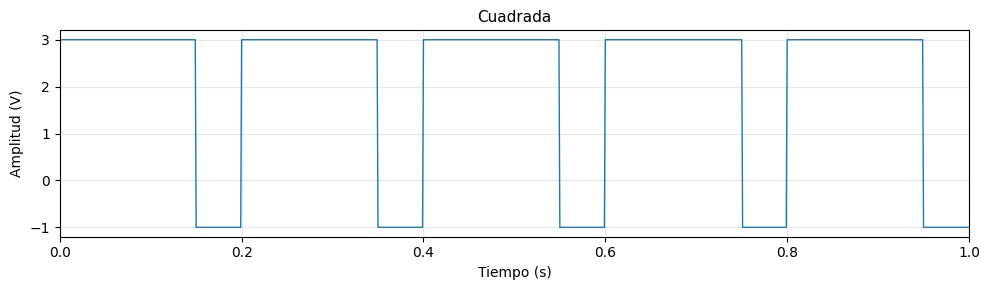

In [6]:
# Visualización
tt, xx = signal(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs, wave='square', duty=duty)
plt.figure(figsize=(10, 3))
plt.plot(tt, xx, linewidth=1)
plt.title("Cuadrada", fontsize=11)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.tight_layout()
plt.show()

### Señal Triangular:

In [7]:
# Parametros de la Señal
ff   = 5 # Hz
vmax = 1 
dc   = 1
ph   = np.pi/2

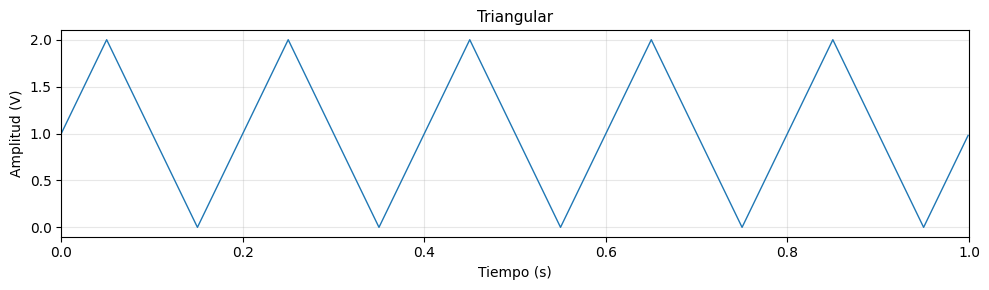

In [8]:
# Visualización
tt, xx = signal(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs, wave='triangle')
plt.figure(figsize=(10, 3))
plt.plot(tt, xx, linewidth=1)
plt.title("Triangular", fontsize=11)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.tight_layout()
plt.show()

### Señal Diente de Sierra:

In [9]:
# Parametros de la Señal
ff   = 10 # Hz
vmax = 5 
dc   = 0
ph   = 0

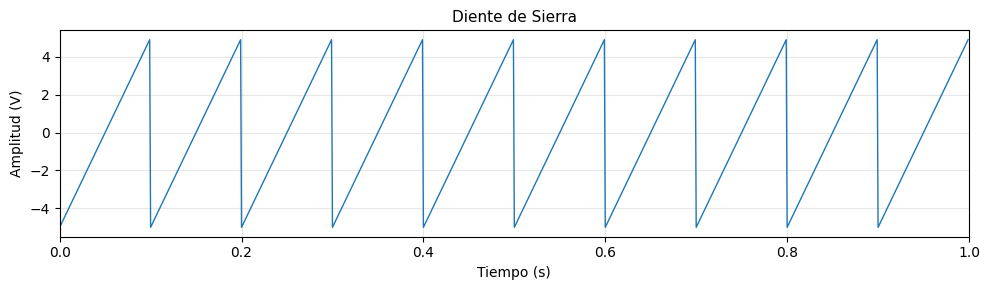

In [10]:
# Visualización
tt, xx = signal(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs, wave='sawtooth')
plt.figure(figsize=(10, 3))
plt.plot(tt, xx, linewidth=1)
plt.title("Diente de Sierra", fontsize=11)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.tight_layout()
plt.show()

## **Extra:** Generador de Señales con ruido:
### Generador de Ruido con distribución normal:
En primer lugar debemos contruir una función que genere ruido con distribución normal:

In [11]:
def noise(nn=1000, fs=1000, mean=0, std=1):
    
    tt  = np.arange(start = 0, step = 1/fs, stop = nn/fs)
    ww  = np.random.normal(loc=mean, scale=std, size= nn)
    
    return tt, ww

### Generador de Señales con Ruido.
Como sabemos la potencia de ruido es igual a la varianza de la señal ruido. Asimismo, podemos calcular la potencia de la señal (sin ruido) generada matematicamente. De esta forma podemos despejar el desvío estándar del ruido que necesitaremos para obtener una determinada SNR. Finalmente, construimos un nuevo generador de señales al que añadimos el parámetro SNR.

In [12]:
def signal_n(wave='sine', vmax=1, dc=0, ff=1, ph=0, nn=1000, fs=1000, duty=0.5, snr=10):
   
    tt, xx = signal(wave=wave, vmax=vmax, dc=dc, ff=ff, ph=ph, nn=nn, fs=fs, duty=duty)

    # Potencia de la señal (ignoramos la potencia de DC para no aumentar artificialmente la SNR)
    p_signal = np.mean((xx - dc) ** 2)

    # P_ruido = P_señal / 10^(SNR/10)
    p_noise  = p_signal / (10 ** (snr / 10))
    # P_ruido = var
    std_noise  = np.sqrt(p_noise)

    _, ww  = noise(nn=nn, fs=fs, mean=0, std=std_noise)
    xx_n   = xx + ww
    
    return tt, xx_n

### Gráficos.

In [13]:
# Parametros de la Señal
ff   = 5 # Hz
vmax = 1 
dc   = 0
ph   = np.pi

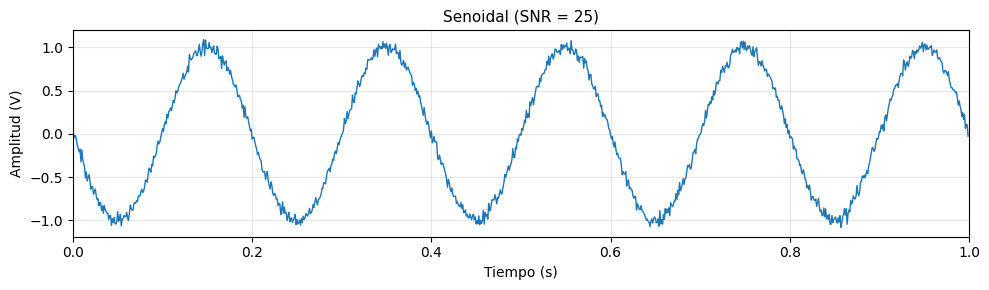

In [14]:
# Visualización
tt, xx = signal_n(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs, wave='sine', snr = 25)
plt.figure(figsize=(10, 3))
plt.plot(tt, xx, linewidth=1)
plt.title("Senoidal (SNR = 25)", fontsize=11)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.grid(True, alpha=0.3)
plt.xlim([0, 1])
plt.tight_layout()
plt.show()

## **Anexo**: Experimentación con frecuencias superiores:
Analizamos que sucede con señales senoidales y frecuencias superiores a la frecuencia de Nyquist

In [15]:
# Condiciones de muestreo
N    = 1000 # Muestras
fs   = 1000 # AF = 1

### ff = fs/2:
#### ph = 0

In [16]:
# Parametros de la Señal
ff   = fs/2 # Hz
vmax = 1 
dc   = 0
ph   = 0

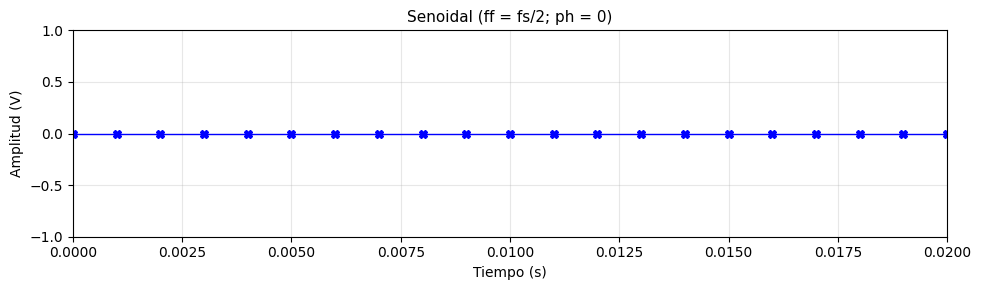

In [17]:
# Visualización
tt, xx = signal(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs, wave='sine')
plt.figure(figsize=(10, 3))
plt.plot(tt, xx, linewidth=1, marker = 'X', color = 'b', linestyle = '-')
plt.title("Senoidal (ff = fs/2; ph = 0)", fontsize=11)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.grid(True, alpha=0.3)
plt.ylim([-vmax, vmax])
plt.xlim([0, 10/ff])
plt.tight_layout()
plt.show()

En este caso, estamos tomando 2 muestras por periodo. Debido a la caracteristica senoidal de la señal ambas coinciden en el valor nulo. Podemos evitar esto modificando la fase:
#### ph = pi/2

In [18]:
# Parametros de la Señal
ff   = fs/2 # Hz
vmax = 1 
dc   = 0
ph   = np.pi/2

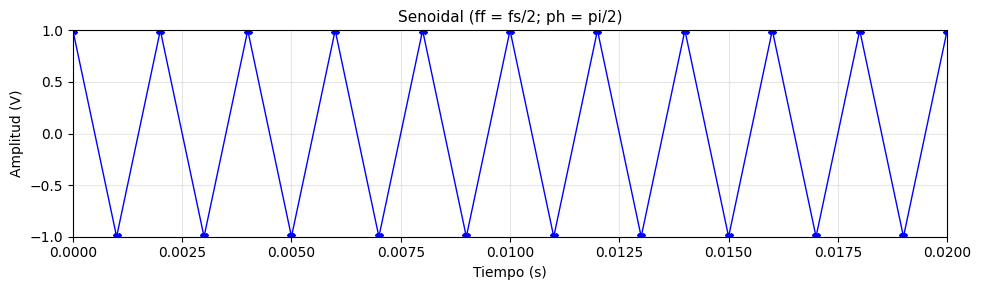

In [19]:
# Visualización
tt, xx = signal(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs, wave='sine')
plt.figure(figsize=(10, 3))
plt.plot(tt, xx, linewidth=1, marker = 'X', color = 'b', linestyle = '-')
plt.title("Senoidal (ff = fs/2; ph = pi/2)", fontsize=11)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.grid(True, alpha=0.3)
plt.ylim([-vmax, vmax])
plt.xlim([0, 10/ff])
plt.tight_layout()
plt.show()

Ahora notamos que cada muestra cae en el valor máximo y minímo de la senoidal en cada periodo.
### ff = fs - 1:

In [20]:
# Parametros de la Señal
ff   = fs - 1 # Hz
vmax = 1 
dc   = 0
ph   = 0

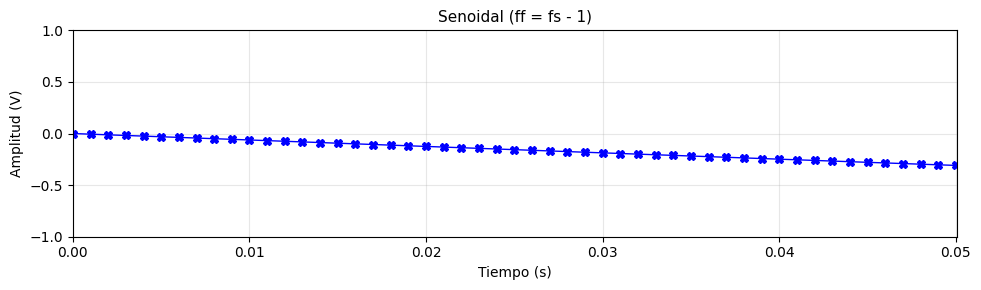

In [21]:
# Visualización
tt, xx = signal(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs, wave='sine')
plt.figure(figsize=(10, 3))
plt.plot(tt, xx, linewidth=1, marker = 'X', color = 'b', linestyle = '-')
plt.title("Senoidal (ff = fs - 1)", fontsize=11)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.grid(True, alpha=0.3)
plt.ylim([-vmax, vmax])
plt.xlim([0, 50/ff]) #Graficamos 50 periodos.
plt.tight_layout()
plt.show()


Si nos encontrasemos exactamente en ff = fs, tendriamos una muestra por periodo siempre tomada en el mismo punto, por lo que obtendriamos un "recta" de puntos del mismo valor. Al alejarnos ligeramente de fs, si graficamos suficientes periodos notamos como cada muestra se desplaza del valor inicial. De cierta forma, la muestra se va "adelantando" con respecto a la señal. Lo opuesto sucede si colocamos una señal por encima de fs.
### ff = fs + 1:

In [22]:
# Parametros de la Señal
ff   = fs + 1 # Hz
vmax = 1 
dc   = 0
ph   = 0

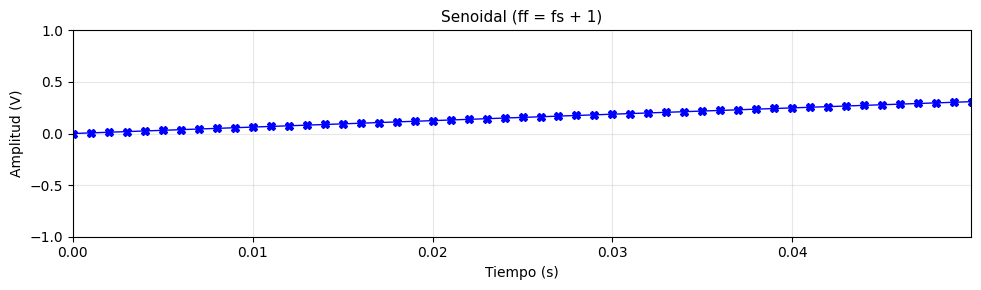

In [23]:
# Visualización
tt, xx = signal(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs, wave='sine')
plt.figure(figsize=(10, 3))
plt.plot(tt, xx, linewidth=1, marker = 'X', color = 'b', linestyle = '-')
plt.title("Senoidal (ff = fs + 1)", fontsize=11)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.grid(True, alpha=0.3)
plt.ylim([-vmax, vmax])
plt.xlim([0, 50/ff]) #Graficamos 50 periodos.
plt.tight_layout()
plt.show()



Tal como se menciono antes, la muestra se "atrasa" con respecto a la señal. Si  colocamos una señal de 2fs, tendremos una muestra cada dos ciclos. Si nos movemos ligeramente de esa frecuencia obtenemos un fenomeno similar al anterior.

### ff = 2fs + 1:

In [24]:
# Parametros de la Señal
ff   = 2*fs + 1 # Hz
vmax = 1 
dc   = 0
ph   = 0

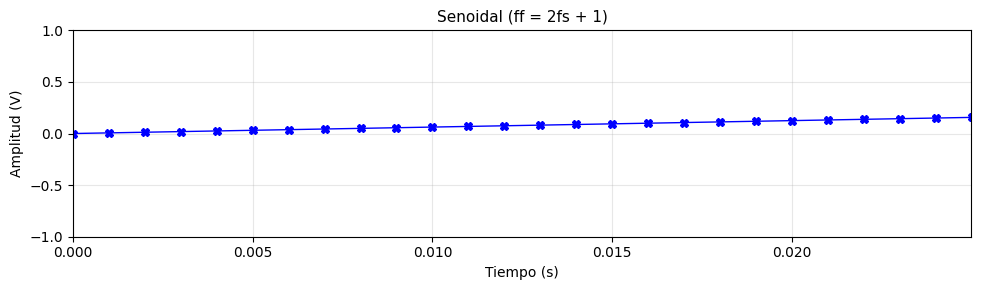

In [25]:
# Visualización
tt, xx = signal(vmax=vmax, dc=dc, ff=ff, ph=ph, nn=N, fs=fs, wave='sine')
plt.figure(figsize=(10, 3))
plt.plot(tt, xx, linewidth=1, marker = 'X', color = 'b', linestyle = '-')
plt.title("Senoidal (ff = 2fs + 1)", fontsize=11)
plt.xlabel("Tiempo (s)")
plt.ylabel("Amplitud (V)")
plt.grid(True, alpha=0.3)
plt.ylim([-vmax, vmax])
plt.xlim([0, 50/ff]) #Graficamos 50 periodos.
plt.tight_layout()
plt.show()
